<a href="https://colab.research.google.com/github/odeandialamsyah/Prediksi-Harga-Komoditas-Pangan/blob/main/Prediksi_Harga_Komoditas_Pangan_Bulanan_Menggunakan_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Library

In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Library berhasil diimport")

Library berhasil diimport


##Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the Excel file into a DataFrame
file_path = '/content/drive/MyDrive/tb_data/1778217759.xlsx'
df = pd.read_excel(file_path)

print("Dataset berhasil dibaca")
print("Ukuran dataset:", df.shape)

Dataset berhasil dibaca
Ukuran dataset: (1227, 4)


##Exploratory Data Analysis / EDA

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Komoditas,Tahun,Bulan,Harga
0,Beras Premium,2021,Januari,Rp12.319
1,Beras Medium,2021,Januari,Rp10.865
2,Kedelai Biji Kering,2021,Januari,Rp10.607
3,Bawang Merah,2021,Januari,Rp30.329
4,Bawang Putih (Bonggol),2021,Januari,Rp26.308


In [ ]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Komoditas  1227 non-null   object
 1   Tahun      1227 non-null   int64 
 2   Bulan      1227 non-null   object
 3   Harga      1227 non-null   object
dtypes: int64(1), object(3)
memory usage: 38.5+ KB


In [ ]:
# Display descriptive statistics
display(df.describe(include="all"))

,Komoditas,Tahun,Bulan,Harga
count,1227,1227.000000,1227,1227
unique,47,NaN,12,1186
top,Cabai Rawit Merah,NaN,Februari,-
freq,64,NaN,120,16
mean,NaN,2023.546862,NaN,NaN
std,NaN,1.522012,NaN,NaN
min,NaN,2021.000000,NaN,NaN
25%,NaN,2022.000000,NaN,NaN
50%,NaN,2024.000000,NaN,NaN
75%,NaN,2025.000000,NaN,NaN


In [ ]:
# Mengecek dataset menggunakan isnull().sum()
missing_awal = df.isnull().sum().reset_index()
missing_awal.columns = ["Kolom", "Jumlah_Missing"]

display(missing_awal)

print("Total missing value awal:", df.isnull().sum().sum())

,Kolom,Jumlah_Missing
0,Komoditas,0
1,Tahun,0
2,Bulan,0
3,Harga,0


Total missing value awal: 0


In [ ]:
print("Jumlah duplikasi seluruh baris:", df.duplicated().sum())

Jumlah duplikasi seluruh baris: 0


In [ ]:
print("Nama kolom:")
print(df.columns.tolist())

Nama kolom:
['Komoditas', 'Tahun', 'Bulan', 'Harga']


In [ ]:
print("Jumlah komoditas unik:", df["Komoditas"].nunique())

display(df["Komoditas"].value_counts())

Jumlah komoditas unik: 47


,count
Komoditas,
Cabai Rawit Merah,64
Minyak Goreng Kemasan,48
Tepung Terigu Curah,48
Gula Pasir Lokal/Curah,48
Telur Ayam Ras,48
Daging Ayam Ras,48
Daging Sapi Murni,48
Beras Premium,36
Beras Medium,36


In [ ]:
print("Daftar bulan:")
print(df["Bulan"].unique())

display(df["Bulan"].value_counts())

Daftar bulan:
['Januari' 'Februari' 'Maret' 'April' 'Mei' 'Juni' 'Juli' 'Agustus'
 'September' 'Oktober' 'November' 'Desember']


,count
Bulan,
Februari,120
Maret,120
April,120
Januari,116
Juni,94
Juli,94
Agustus,94
September,94
November,94


In [ ]:
df_eda = df.copy()

df_eda.columns = df_eda.columns.str.strip()

df_eda["Komoditas"] = df_eda["Komoditas"].astype(str).str.strip()
df_eda["Bulan"] = df_eda["Bulan"].astype(str).str.strip()

df_eda["Harga"] = (
    df_eda["Harga"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df_eda["Harga"] = df_eda["Harga"].replace("", np.nan)
df_eda["Harga"] = pd.to_numeric(df_eda["Harga"], errors="coerce")

display(df_eda.head())

,Komoditas,Tahun,Bulan,Harga
0,Beras Premium,2021,Januari,12319.0
1,Beras Medium,2021,Januari,10865.0
2,Kedelai Biji Kering,2021,Januari,10607.0
3,Bawang Merah,2021,Januari,30329.0
4,Bawang Putih (Bonggol),2021,Januari,26308.0


###Visualisasi Jumlah Data Per Komoditas

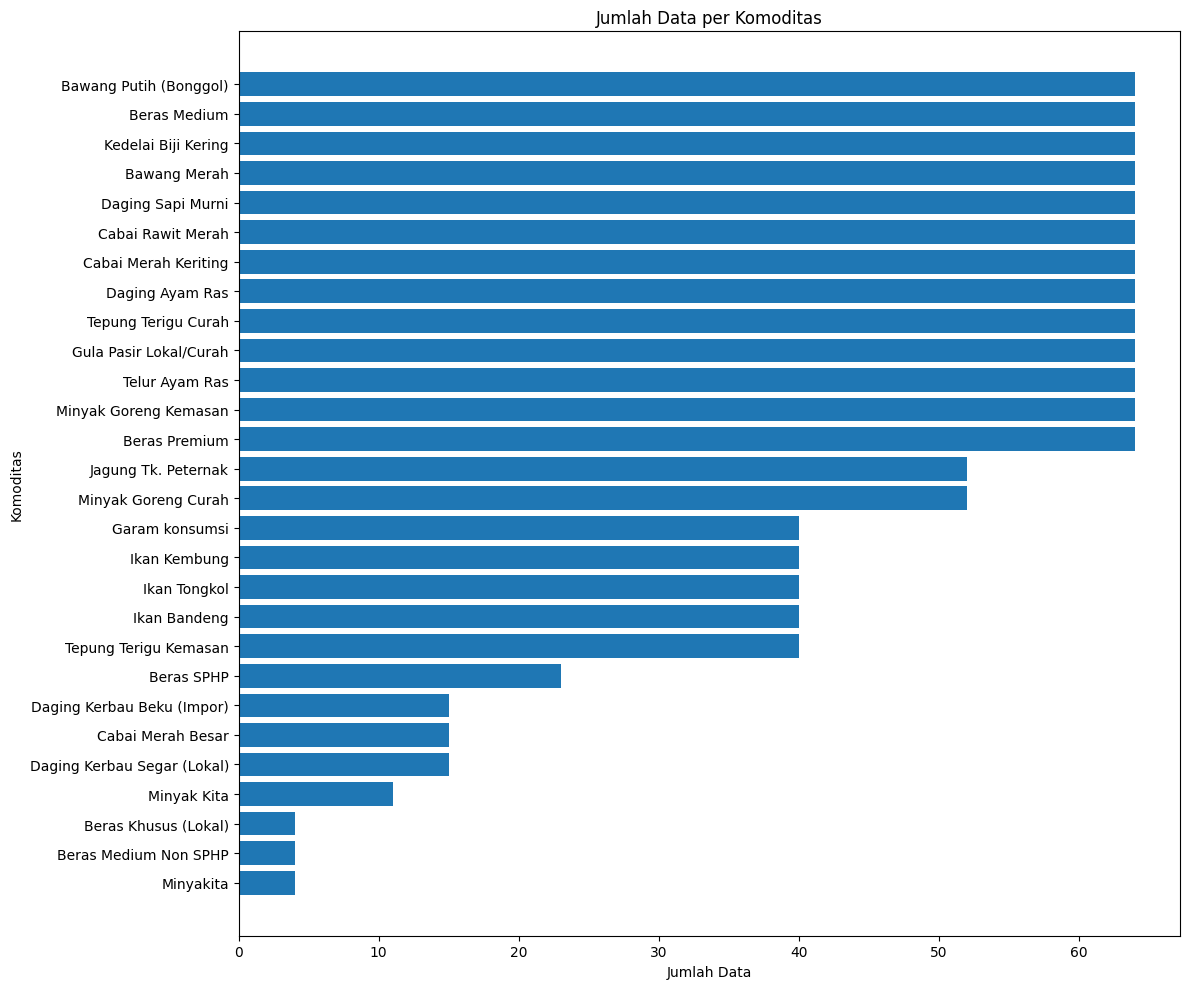

In [ ]:
jumlah_komoditas = df_eda["Komoditas"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(jumlah_komoditas.index, jumlah_komoditas.values)
plt.title("Jumlah Data per Komoditas")
plt.xlabel("Jumlah Data")
plt.ylabel("Komoditas")
plt.tight_layout()
plt.show()

Mengetahui komoditas mana yang memiliki data paling banyak dan paling sedikit.

###Visualisasi Jumlah Data Per Tahun

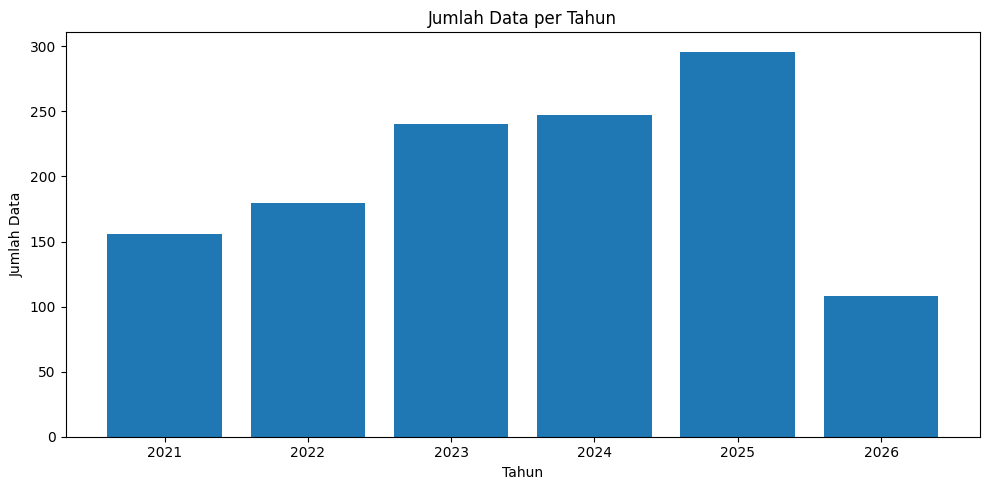

In [ ]:
jumlah_tahun = df_eda["Tahun"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(jumlah_tahun.index.astype(str), jumlah_tahun.values)
plt.title("Jumlah Data per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

Melihat sebaran jumlah data pada setiap tahun.

###Visualisasi Jumlah Data Per Bulan

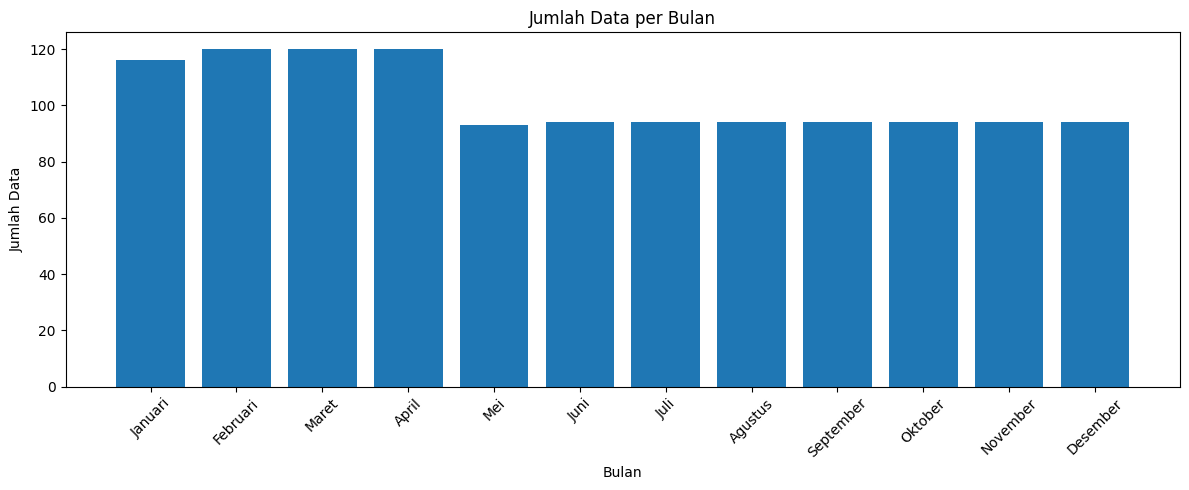

In [ ]:
urutan_bulan = [
    "Januari", "Februari", "Maret", "April", "Mei", "Juni",
    "Juli", "Agustus", "September", "Oktober", "November", "Desember"
]

jumlah_bulan = df_eda["Bulan"].value_counts().reindex(urutan_bulan)

plt.figure(figsize=(12, 5))
plt.bar(jumlah_bulan.index, jumlah_bulan.values)
plt.title("Jumlah Data per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Melihat apakah data bulanan tersedia secara merata atau ada bulan tertentu yang lebih sedikit.

###Visualisasi Distribusi Harga Komoditas

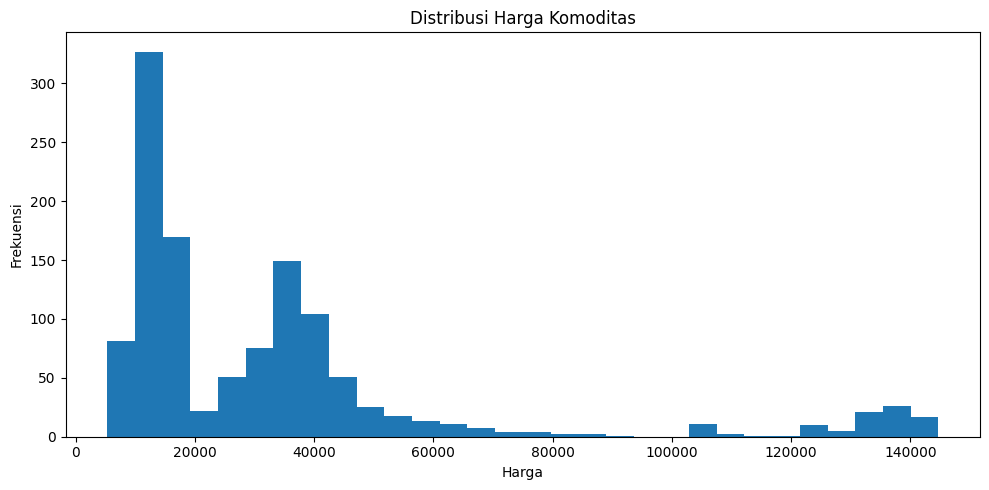

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_eda["Harga"].dropna(), bins=30)
plt.title("Distribusi Harga Komoditas")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

Melihat sebaran harga komoditas dan kemungkinan adanya harga ekstrem.

###Boxplot Harga Komoditas

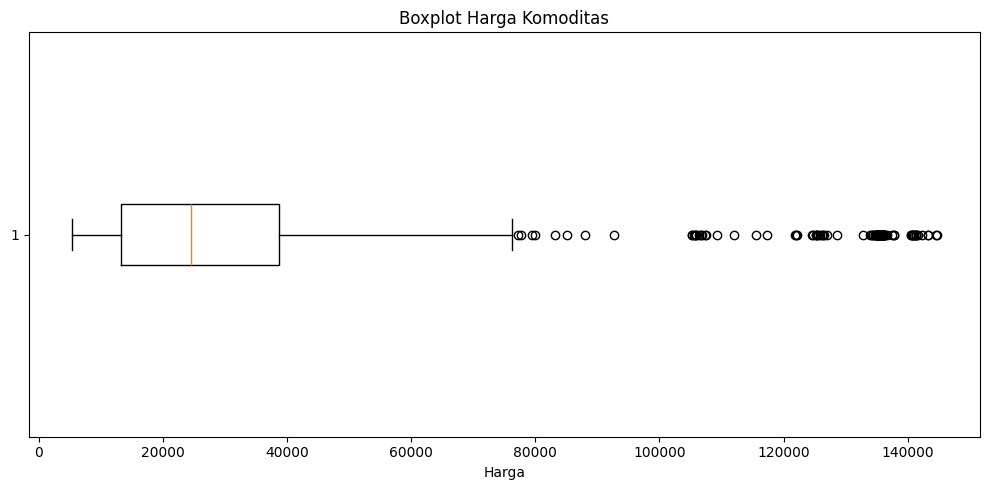

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_eda["Harga"].dropna(), vert=False)
plt.title("Boxplot Harga Komoditas")
plt.xlabel("Harga")
plt.tight_layout()
plt.show()

Melihat indikasi outlier pada harga komoditas.

###Visualisasi Rata-Rata Harga Per Komoditas

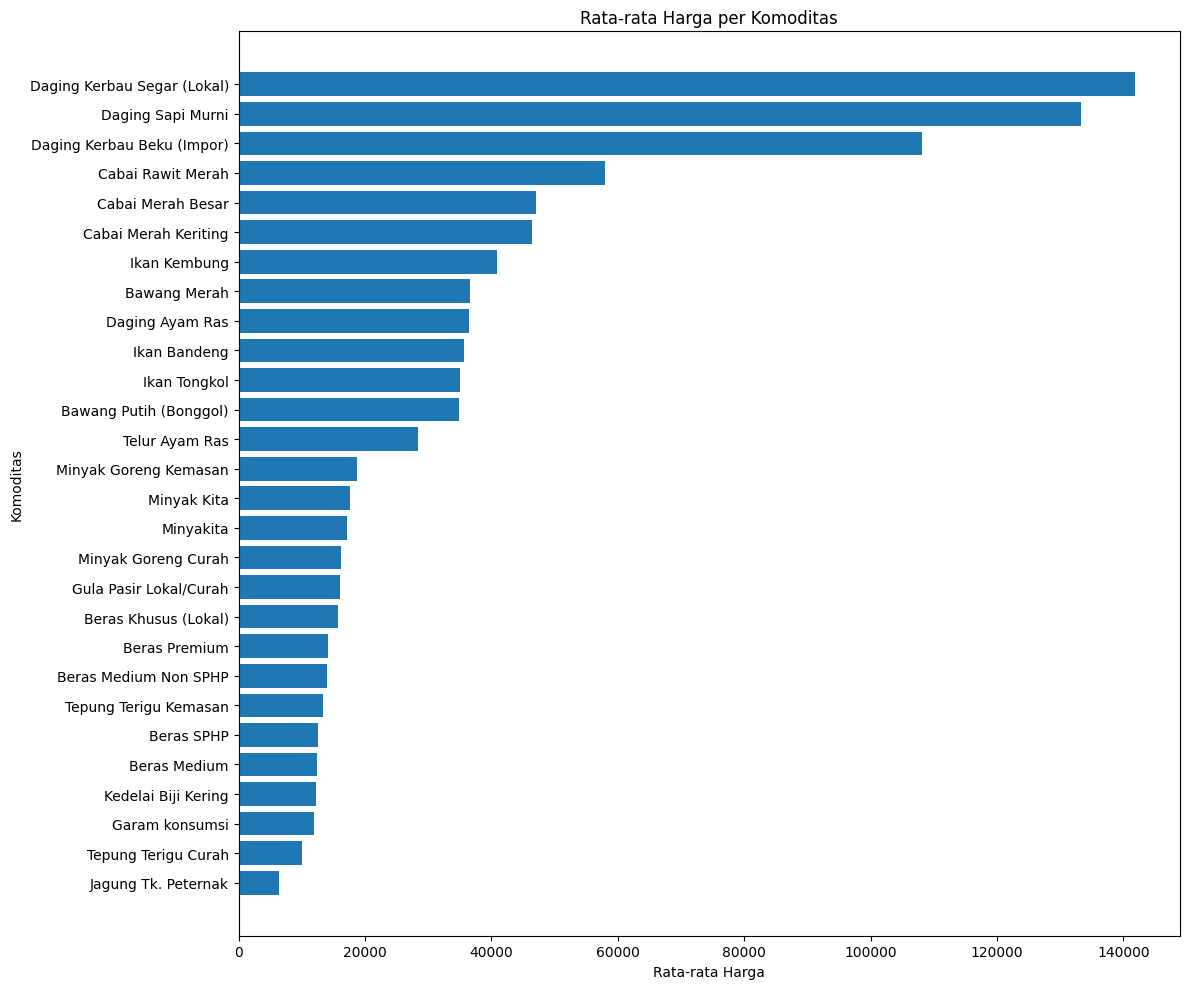

In [ ]:
rata_harga_komoditas = (
    df_eda.groupby("Komoditas")["Harga"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 10))
plt.barh(rata_harga_komoditas.index, rata_harga_komoditas.values)
plt.title("Rata-rata Harga per Komoditas")
plt.xlabel("Rata-rata Harga")
plt.ylabel("Komoditas")
plt.tight_layout()
plt.show()

Mengetahui komoditas dengan rata-rata harga tertinggi dan terendah.

###Visualisasi Tren Rata-Rata Harga Per Tahun

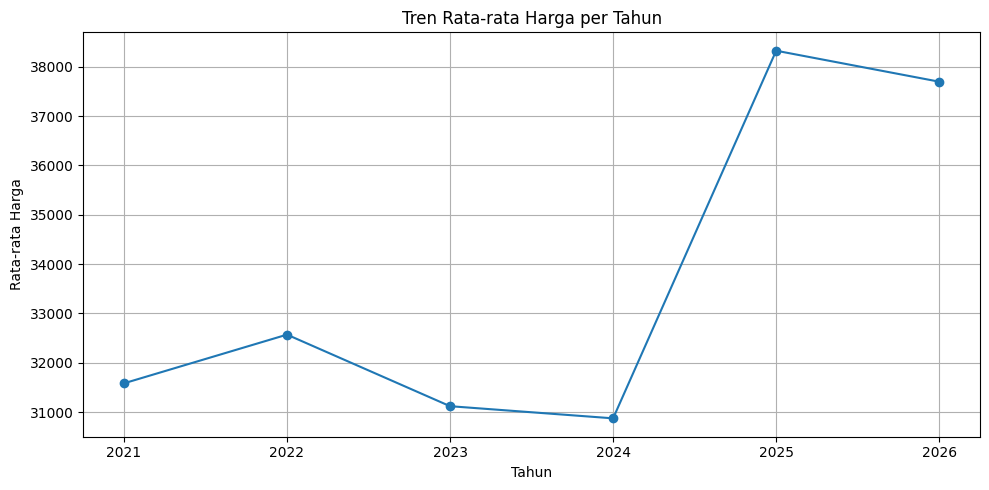

In [ ]:
tren_tahunan = df_eda.groupby("Tahun")["Harga"].mean()

plt.figure(figsize=(10, 5))
plt.plot(tren_tahunan.index, tren_tahunan.values, marker="o")
plt.title("Tren Rata-rata Harga per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Harga")
plt.grid(True)
plt.tight_layout()
plt.show()

Melihat perubahan rata-rata harga pangan dari tahun ke tahun.

###Visualisasi Tren Harga Beberapa Komoditas

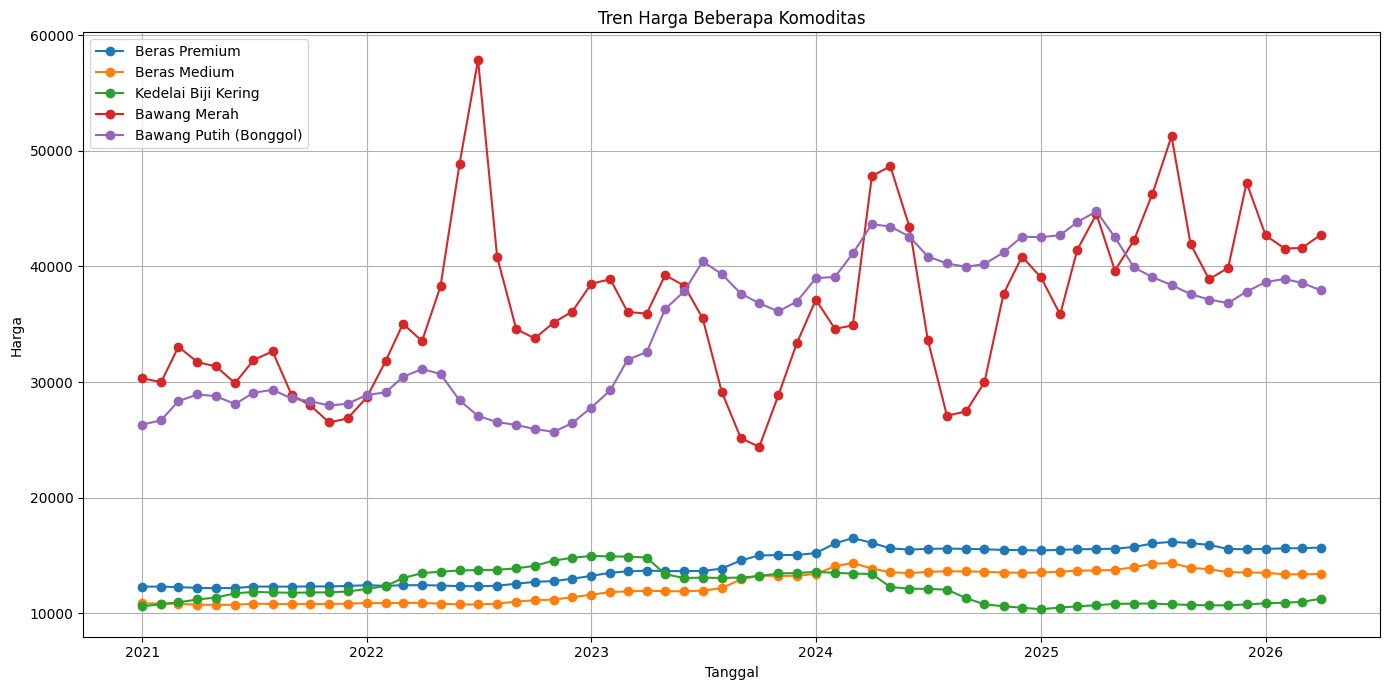

In [ ]:
bulan_mapping_eda = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

df_eda["Bulan_Num"] = df_eda["Bulan"].map(bulan_mapping_eda)

df_eda["Tanggal"] = pd.to_datetime(
    df_eda["Tahun"].astype(str) + "-" + df_eda["Bulan_Num"].astype("Int64").astype(str) + "-01",
    errors="coerce"
)

top_komoditas = df_eda["Komoditas"].value_counts().head(5).index.tolist()

plt.figure(figsize=(14, 7))

for komoditas in top_komoditas:
    subset = df_eda[df_eda["Komoditas"] == komoditas].sort_values("Tanggal")
    plt.plot(subset["Tanggal"], subset["Harga"], marker="o", label=komoditas)

plt.title("Tren Harga Beberapa Komoditas")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Melihat pola perubahan harga beberapa komoditas dari waktu ke waktu.

###Heatmap Rata-rata Harga per Tahun dan Bulan

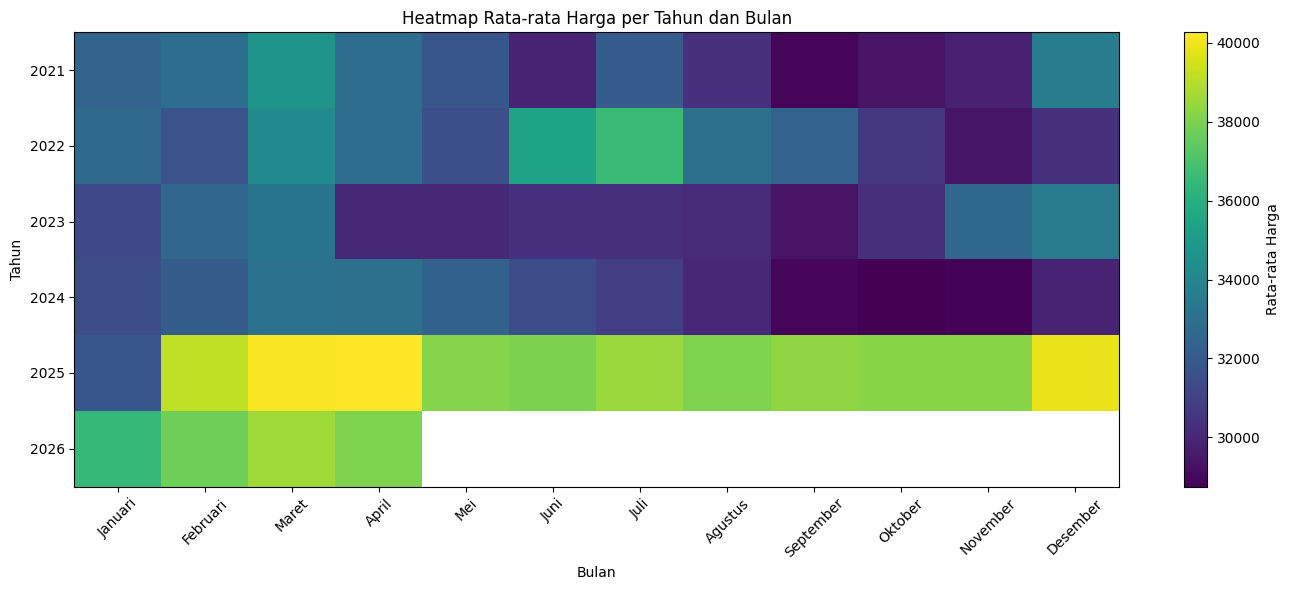

In [ ]:
pivot_harga = df_eda.pivot_table(
    values="Harga",
    index="Tahun",
    columns="Bulan",
    aggfunc="mean"
)

pivot_harga = pivot_harga.reindex(columns=urutan_bulan)

plt.figure(figsize=(14, 6))
plt.imshow(pivot_harga, aspect="auto")
plt.colorbar(label="Rata-rata Harga")
plt.title("Heatmap Rata-rata Harga per Tahun dan Bulan")
plt.xlabel("Bulan")
plt.ylabel("Tahun")
plt.xticks(range(len(pivot_harga.columns)), pivot_harga.columns, rotation=45)
plt.yticks(range(len(pivot_harga.index)), pivot_harga.index)
plt.tight_layout()
plt.show()

Melihat pola rata-rata harga berdasarkan kombinasi tahun dan bulan.

##Pre-Processing

###Cleaning nama kolom dan teks

In [ ]:
# Cleaning nama kolom dan data teks pada dataset utama
df.columns = df.columns.str.strip()

df["Komoditas"] = df["Komoditas"].astype(str).str.strip()
df["Bulan"] = df["Bulan"].astype(str).str.strip()

print("Nama kolom setelah cleaning:")
print(df.columns.tolist())

print("Jumlah komoditas setelah cleaning:", df["Komoditas"].nunique())
print("Daftar bulan setelah cleaning:")
print(df["Bulan"].unique())

Nama kolom setelah cleaning:
['Komoditas', 'Tahun', 'Bulan', 'Harga']
Jumlah komoditas setelah cleaning: 28
Daftar bulan setelah cleaning:
['Januari' 'Februari' 'Maret' 'April' 'Mei' 'Juni' 'Juli' 'Agustus'
 'September' 'Oktober' 'November' 'Desember']


###Cleaning Harga dengan Vectorized Operation

In [ ]:
# Cleaning harga secara vectorized
df["Harga"] = (
    df["Harga"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

# Ubah string kosong menjadi NaN
df["Harga"] = df["Harga"].replace("", np.nan)

# Konversi ke numerik float
df["Harga"] = pd.to_numeric(df["Harga"], errors="coerce").astype(float)

print("Tipe data Harga setelah cleaning:", df["Harga"].dtype)
print("Jumlah missing Harga:", df["Harga"].isnull().sum())

display(df[df["Harga"].isnull()][["Komoditas", "Tahun", "Bulan", "Harga"]].head(30))

Tipe data Harga setelah cleaning: float64
Jumlah missing Harga: 16


,Komoditas,Tahun,Bulan,Harga
169,Minyak Goreng Curah,2022,Januari,NaN
170,Jagung Tk. Peternak,2022,Januari,NaN
184,Minyak Goreng Curah,2022,Februari,NaN
185,Jagung Tk. Peternak,2022,Februari,NaN
199,Minyak Goreng Curah,2022,Maret,NaN
200,Jagung Tk. Peternak,2022,Maret,NaN
215,Jagung Tk. Peternak,2022,April,NaN
348,Tepung Terigu Kemasan,2023,Januari,NaN
352,Ikan Kembung,2023,Januari,NaN
353,Ikan Tongkol,2023,Januari,NaN


###Imputasi Missing Value Harga

In [ ]:
print("Missing Harga sebelum imputasi:", df["Harga"].isna().sum())

df["Harga"] = df.groupby("Komoditas")["Harga"].transform(
    lambda x: x.interpolate(method="linear")
)

df["Harga"] = df.groupby("Komoditas")["Harga"].transform(
    lambda x: x.ffill().bfill()
)

print("Missing Harga setelah imputasi:", df["Harga"].isna().sum())

Missing Harga sebelum imputasi: 16
Missing Harga setelah imputasi: 0


In [ ]:
display(df[df["Harga"].isnull()][["Komoditas", "Tahun", "Bulan", "Harga"]].head(30))

,Komoditas,Tahun,Bulan,Harga


###Statistik Harga Setelah Cleaning

In [ ]:
display(df["Harga"].describe())

statistik_komoditas = df.groupby("Komoditas")["Harga"].agg(
    Jumlah_Data="count",
    Harga_Min="min",
    Harga_Rata_Rata="mean",
    Harga_Max="max",
    Harga_Std="std"
).reset_index()

display(statistik_komoditas.sort_values("Harga_Rata_Rata", ascending=False))

,Harga
count,1227.000000
mean,33463.171149
std,31767.950390
min,5312.000000
25%,13249.500000
50%,24036.000000
75%,38627.500000
max,144686.000000


,Komoditas,Jumlah_Data,Harga_Min,Harga_Rata_Rata,Harga_Max,Harga_Std
12,Daging Kerbau Segar (Lokal),15,140557.0,141881.066667,144686.0,1387.470230
13,Daging Sapi Murni,64,121836.0,133266.328125,141350.0,4774.770045
11,Daging Kerbau Beku (Impor),15,105220.0,108166.666667,117260.0,3807.435314
9,Cabai Rawit Merah,64,35465.0,58045.406250,92656.0,13662.674476
7,Cabai Merah Besar,15,38269.0,47073.933333,54278.0,4998.236453
8,Cabai Merah Keriting,64,28052.0,46410.609375,76189.0,10095.949145
17,Ikan Kembung,40,38235.0,40836.850000,46233.0,1923.913327
0,Bawang Merah,64,24403.0,36547.656250,57859.0,6918.365408
10,Daging Ayam Ras,64,33457.0,36443.625000,41312.0,1727.411427
16,Ikan Bandeng,40,33523.0,35597.425000,38691.0,1373.396200


###Encoding Bulan Langsung pada Kolom Bulan

In [ ]:
bulan_mapping = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

bulan_inverse_mapping = {
    1: "Januari",
    2: "Februari",
    3: "Maret",
    4: "April",
    5: "Mei",
    6: "Juni",
    7: "Juli",
    8: "Agustus",
    9: "September",
    10: "Oktober",
    11: "November",
    12: "Desember"
}

df["Bulan"] = df["Bulan"].map(bulan_mapping)

print("Jumlah bulan gagal dikonversi:", df["Bulan"].isna().sum())
print("Daftar bulan setelah encoding:")
print(sorted(df["Bulan"].dropna().unique()))

display(df.head())

Jumlah bulan gagal dikonversi: 0
Daftar bulan setelah encoding:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,Komoditas,Tahun,Bulan,Harga
0,Beras Premium,2021,1,12319.0
1,Beras Medium,2021,1,10865.0
2,Kedelai Biji Kering,2021,1,10607.0
3,Bawang Merah,2021,1,30329.0
4,Bawang Putih (Bonggol),2021,1,26308.0


###Membuat Kolom Tanggal

In [ ]:
df["Tanggal"] = pd.to_datetime(
    df["Tahun"].astype(str) + "-" + df["Bulan"].astype("Int64").astype(str) + "-01",
    errors="coerce"
)

print("Tanggal tidak valid:", df["Tanggal"].isna().sum())
print("Tanggal awal:", df["Tanggal"].min())
print("Tanggal akhir:", df["Tanggal"].max())

df = df.sort_values(["Komoditas", "Tanggal"]).reset_index(drop=True)

display(df.head())

Tanggal tidak valid: 0
Tanggal awal: 2021-01-01 00:00:00
Tanggal akhir: 2026-04-01 00:00:00


,Komoditas,Tahun,Bulan,Harga,Tanggal
0,Bawang Merah,2021,1,30329.0,2021-01-01
1,Bawang Merah,2021,2,29996.0,2021-02-01
2,Bawang Merah,2021,3,33050.0,2021-03-01
3,Bawang Merah,2021,4,31729.0,2021-04-01
4,Bawang Merah,2021,5,31355.0,2021-05-01


###Deteksi Outlier Harga

In [ ]:
def detect_outlier_iqr(group):
    q1 = group["Harga"].quantile(0.25)
    q3 = group["Harga"].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    group["Outlier"] = (group["Harga"] < lower_bound) | (group["Harga"] > upper_bound)

    return group

df = df.groupby("Komoditas", group_keys=False).apply(detect_outlier_iqr)

print("Jumlah outlier:", df["Outlier"].sum())

display(
    df[df["Outlier"] == True][
        ["Komoditas", "Tahun", "Bulan", "Harga"]
    ].head(30)
)

Jumlah outlier: 45


,Komoditas,Tahun,Bulan,Harga
18,Bawang Merah,2022,7,57859.0
131,Beras Khusus (Lokal),2026,4,15951.0
264,Beras SPHP,2024,6,13188.0
265,Beras SPHP,2024,7,12819.0
320,Cabai Merah Keriting,2022,7,76189.0
492,Daging Ayam Ras,2026,3,41312.0
507,Daging Kerbau Beku (Impor),2026,3,115594.0
508,Daging Kerbau Beku (Impor),2026,4,117260.0
524,Daging Sapi Murni,2021,1,121836.0
525,Daging Sapi Murni,2021,2,122182.0


###Feature Engineering: Lag Harga

Fitur lag digunakan agar model dapat mempelajari pola harga dari bulan sebelumnya.

In [ ]:
df["Harga_Lag_1"] = df.groupby("Komoditas")["Harga"].shift(1)
df["Harga_Lag_2"] = df.groupby("Komoditas")["Harga"].shift(2)
df["Harga_Lag_3"] = df.groupby("Komoditas")["Harga"].shift(3)

display(
    df[
        [
            "Komoditas",
            "Tanggal",
            "Tahun",
            "Bulan",
            "Harga",
            "Harga_Lag_1",
            "Harga_Lag_2",
            "Harga_Lag_3"
        ]
    ].head(15)
)

,Komoditas,Tanggal,Tahun,Bulan,Harga,Harga_Lag_1,Harga_Lag_2,Harga_Lag_3
0,Bawang Merah,2021-01-01,2021,1,30329.0,NaN,NaN,NaN
1,Bawang Merah,2021-02-01,2021,2,29996.0,30329.0,NaN,NaN
2,Bawang Merah,2021-03-01,2021,3,33050.0,29996.0,30329.0,NaN
3,Bawang Merah,2021-04-01,2021,4,31729.0,33050.0,29996.0,30329.0
4,Bawang Merah,2021-05-01,2021,5,31355.0,31729.0,33050.0,29996.0
5,Bawang Merah,2021-06-01,2021,6,29914.0,31355.0,31729.0,33050.0
6,Bawang Merah,2021-07-01,2021,7,31897.0,29914.0,31355.0,31729.0
7,Bawang Merah,2021-08-01,2021,8,32657.0,31897.0,29914.0,31355.0
8,Bawang Merah,2021-09-01,2021,9,28890.0,32657.0,31897.0,29914.0
9,Bawang Merah,2021-10-01,2021,10,28004.0,28890.0,32657.0,31897.0


###Feature Engineering: Moving Average

In [ ]:
df["Moving_Average_3"] = df.groupby("Komoditas")["Harga"].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

df["Moving_Average_6"] = df.groupby("Komoditas")["Harga"].transform(
    lambda x: x.shift(1).rolling(window=6).mean()
)

display(
    df[
        [
            "Komoditas",
            "Tanggal",
            "Harga",
            "Moving_Average_3",
            "Moving_Average_6"
        ]
    ].head(15)
)

,Komoditas,Tanggal,Harga,Moving_Average_3,Moving_Average_6
0,Bawang Merah,2021-01-01,30329.0,NaN,NaN
1,Bawang Merah,2021-02-01,29996.0,NaN,NaN
2,Bawang Merah,2021-03-01,33050.0,NaN,NaN
3,Bawang Merah,2021-04-01,31729.0,31125.000000,NaN
4,Bawang Merah,2021-05-01,31355.0,31591.666667,NaN
5,Bawang Merah,2021-06-01,29914.0,32044.666667,NaN
6,Bawang Merah,2021-07-01,31897.0,30999.333333,31062.166667
7,Bawang Merah,2021-08-01,32657.0,31055.333333,31323.500000
8,Bawang Merah,2021-09-01,28890.0,31489.333333,31767.000000
9,Bawang Merah,2021-10-01,28004.0,31148.000000,31073.666667


###Feature Engineering: Perubahan Harga

In [ ]:
df["Perubahan_Harga"] = df["Harga"] - df["Harga_Lag_1"]

df["Persentase_Perubahan_Harga"] = (
    df["Perubahan_Harga"] / df["Harga_Lag_1"]
) * 100

display(
    df[
        [
            "Komoditas",
            "Tanggal",
            "Harga",
            "Perubahan_Harga",
            "Persentase_Perubahan_Harga"
        ]
    ].head(15)
)

,Komoditas,Tanggal,Harga,Perubahan_Harga,Persentase_Perubahan_Harga
0,Bawang Merah,2021-01-01,30329.0,NaN,NaN
1,Bawang Merah,2021-02-01,29996.0,-333.0,-1.097959
2,Bawang Merah,2021-03-01,33050.0,3054.0,10.181358
3,Bawang Merah,2021-04-01,31729.0,-1321.0,-3.996974
4,Bawang Merah,2021-05-01,31355.0,-374.0,-1.178732
5,Bawang Merah,2021-06-01,29914.0,-1441.0,-4.595758
6,Bawang Merah,2021-07-01,31897.0,1983.0,6.629003
7,Bawang Merah,2021-08-01,32657.0,760.0,2.382669
8,Bawang Merah,2021-09-01,28890.0,-3767.0,-11.535046
9,Bawang Merah,2021-10-01,28004.0,-886.0,-3.066805


###Membuat Target Prediksi
Target yang diprediksi adalah harga bulan berikutnya.

In [ ]:
df["Target_Harga_Bulan_Berikutnya"] = df.groupby("Komoditas")["Harga"].shift(-1)

display(
    df[
        [
            "Komoditas",
            "Tanggal",
            "Harga",
            "Target_Harga_Bulan_Berikutnya"
        ]
    ].head(15)
)

,Komoditas,Tanggal,Harga,Target_Harga_Bulan_Berikutnya
0,Bawang Merah,2021-01-01,30329.0,29996.0
1,Bawang Merah,2021-02-01,29996.0,33050.0
2,Bawang Merah,2021-03-01,33050.0,31729.0
3,Bawang Merah,2021-04-01,31729.0,31355.0
4,Bawang Merah,2021-05-01,31355.0,29914.0
5,Bawang Merah,2021-06-01,29914.0,31897.0
6,Bawang Merah,2021-07-01,31897.0,32657.0
7,Bawang Merah,2021-08-01,32657.0,28890.0
8,Bawang Merah,2021-09-01,28890.0,28004.0
9,Bawang Merah,2021-10-01,28004.0,26510.0


###Drop Missing dari Fitur dan Target

Missing muncul karena pembuatan lag, moving average, dan target bulan berikutnya.

In [ ]:
fitur_wajib = [
    "Harga_Lag_1",
    "Harga_Lag_2",
    "Harga_Lag_3",
    "Moving_Average_3",
    "Moving_Average_6",
    "Perubahan_Harga",
    "Persentase_Perubahan_Harga",
    "Target_Harga_Bulan_Berikutnya"
]

print("Ukuran sebelum drop missing:", df.shape)

df_model = df.dropna(subset=fitur_wajib).copy()

print("Ukuran setelah drop missing:", df_model.shape)

display(df_model.head())

Ukuran sebelum drop missing: (1227, 14)
Ukuran setelah drop missing: (1040, 14)


,Komoditas,Tahun,Bulan,Harga,Tanggal,Outlier,Harga_Lag_1,Harga_Lag_2,Harga_Lag_3,Moving_Average_3,Moving_Average_6,Perubahan_Harga,Persentase_Perubahan_Harga,Target_Harga_Bulan_Berikutnya
6,Bawang Merah,2021,7,31897.0,2021-07-01,False,29914.0,31355.0,31729.0,30999.333333,31062.166667,1983.0,6.629003,32657.0
7,Bawang Merah,2021,8,32657.0,2021-08-01,False,31897.0,29914.0,31355.0,31055.333333,31323.500000,760.0,2.382669,28890.0
8,Bawang Merah,2021,9,28890.0,2021-09-01,False,32657.0,31897.0,29914.0,31489.333333,31767.000000,-3767.0,-11.535046,28004.0
9,Bawang Merah,2021,10,28004.0,2021-10-01,False,28890.0,32657.0,31897.0,31148.000000,31073.666667,-886.0,-3.066805,26510.0
10,Bawang Merah,2021,11,26510.0,2021-11-01,False,28004.0,28890.0,32657.0,29850.333333,30452.833333,-1494.0,-5.334952,26854.0


###Encoding Komoditas

In [ ]:
df_model_encoded = pd.get_dummies(
    df_model,
    columns=["Komoditas"],
    drop_first=False
)

print("Ukuran data setelah encoding:", df_model_encoded.shape)

display(df_model_encoded.head())

Ukuran data setelah encoding: (1040, 38)


,Tahun,Bulan,Harga,Tanggal,Outlier,Harga_Lag_1,Harga_Lag_2,Harga_Lag_3,Moving_Average_3,Moving_Average_6,Perubahan_Harga,Persentase_Perubahan_Harga,Target_Harga_Bulan_Berikutnya,Komoditas_Bawang Merah,Komoditas_Bawang Putih (Bonggol),Komoditas_Beras Medium,Komoditas_Beras Premium,Komoditas_Beras SPHP,Komoditas_Cabai Merah Besar,Komoditas_Cabai Merah Keriting,Komoditas_Cabai Rawit Merah,Komoditas_Daging Ayam Ras,Komoditas_Daging Kerbau Beku (Impor),Komoditas_Daging Kerbau Segar (Lokal),Komoditas_Daging Sapi Murni,Komoditas_Garam konsumsi,Komoditas_Gula Pasir Lokal/Curah,Komoditas_Ikan Bandeng,Komoditas_Ikan Kembung,Komoditas_Ikan Tongkol,Komoditas_Jagung Tk. Peternak,Komoditas_Kedelai Biji Kering,Komoditas_Minyak Goreng Curah,Komoditas_Minyak Goreng Kemasan,Komoditas_Minyak Kita,Komoditas_Telur Ayam Ras,Komoditas_Tepung Terigu Curah,Komoditas_Tepung Terigu Kemasan
6,2021,7,31897.0,2021-07-01,False,29914.0,31355.0,31729.0,30999.333333,31062.166667,1983.0,6.629003,32657.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,2021,8,32657.0,2021-08-01,False,31897.0,29914.0,31355.0,31055.333333,31323.500000,760.0,2.382669,28890.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,2021,9,28890.0,2021-09-01,False,32657.0,31897.0,29914.0,31489.333333,31767.000000,-3767.0,-11.535046,28004.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,2021,10,28004.0,2021-10-01,False,28890.0,32657.0,31897.0,31148.000000,31073.666667,-886.0,-3.066805,26510.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10,2021,11,26510.0,2021-11-01,False,28004.0,28890.0,32657.0,29850.333333,30452.833333,-1494.0,-5.334952,26854.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


###Menentukan Fitur dan Target

In [ ]:
target = "Target_Harga_Bulan_Berikutnya"

fitur_numerik = [
    "Tahun",
    "Bulan",
    "Harga",
    "Harga_Lag_1",
    "Harga_Lag_2",
    "Harga_Lag_3",
    "Moving_Average_3",
    "Moving_Average_6",
    "Perubahan_Harga",
    "Persentase_Perubahan_Harga"
]

fitur_komoditas = [
    col for col in df_model_encoded.columns
    if col.startswith("Komoditas_")
]

fitur_final = fitur_numerik + fitur_komoditas

X = df_model_encoded[fitur_final]
y = df_model_encoded[target]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

display(X.head())
display(y.head())

Ukuran X: (1040, 35)
Ukuran y: (1040,)


,Tahun,Bulan,Harga,Harga_Lag_1,Harga_Lag_2,Harga_Lag_3,Moving_Average_3,Moving_Average_6,Perubahan_Harga,Persentase_Perubahan_Harga,Komoditas_Bawang Merah,Komoditas_Bawang Putih (Bonggol),Komoditas_Beras Medium,Komoditas_Beras Premium,Komoditas_Beras SPHP,Komoditas_Cabai Merah Besar,Komoditas_Cabai Merah Keriting,Komoditas_Cabai Rawit Merah,Komoditas_Daging Ayam Ras,Komoditas_Daging Kerbau Beku (Impor),Komoditas_Daging Kerbau Segar (Lokal),Komoditas_Daging Sapi Murni,Komoditas_Garam konsumsi,Komoditas_Gula Pasir Lokal/Curah,Komoditas_Ikan Bandeng,Komoditas_Ikan Kembung,Komoditas_Ikan Tongkol,Komoditas_Jagung Tk. Peternak,Komoditas_Kedelai Biji Kering,Komoditas_Minyak Goreng Curah,Komoditas_Minyak Goreng Kemasan,Komoditas_Minyak Kita,Komoditas_Telur Ayam Ras,Komoditas_Tepung Terigu Curah,Komoditas_Tepung Terigu Kemasan
6,2021,7,31897.0,29914.0,31355.0,31729.0,30999.333333,31062.166667,1983.0,6.629003,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,2021,8,32657.0,31897.0,29914.0,31355.0,31055.333333,31323.500000,760.0,2.382669,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,2021,9,28890.0,32657.0,31897.0,29914.0,31489.333333,31767.000000,-3767.0,-11.535046,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,2021,10,28004.0,28890.0,32657.0,31897.0,31148.000000,31073.666667,-886.0,-3.066805,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10,2021,11,26510.0,28004.0,28890.0,32657.0,29850.333333,30452.833333,-1494.0,-5.334952,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


,Target_Harga_Bulan_Berikutnya
6,32657.0
7,28890.0
8,28004.0
9,26510.0
10,26854.0


###Dynamic Time-Based Split

Split dibuat dinamis agar saat data bertambah, pembagian data tetap menyesuaikan.

In [ ]:
df_model_encoded = df_model_encoded.sort_values("Tanggal").reset_index(drop=True)

# Ambil tanggal unik
unique_dates = sorted(df_model_encoded["Tanggal"].unique())

# Tentukan titik split 80% berdasarkan tanggal unik
split_index = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_index]

train_data = df_model_encoded[df_model_encoded["Tanggal"] < split_date]
test_data = df_model_encoded[df_model_encoded["Tanggal"] >= split_date]

X_train = train_data[fitur_final]
y_train = train_data[target]

X_test = test_data[fitur_final]
y_test = test_data[target]

print("Split date:", split_date)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nPeriode train:")
print(train_data["Tanggal"].min(), "sampai", train_data["Tanggal"].max())

print("\nPeriode test:")
print(test_data["Tanggal"].min(), "sampai", test_data["Tanggal"].max())

Split date: 2025-04-01 00:00:00
X_train: (760, 35)
X_test : (280, 35)

Periode train:
2021-07-01 00:00:00 sampai 2025-03-01 00:00:00

Periode test:
2025-04-01 00:00:00 sampai 2026-03-01 00:00:00


###Scaling Fitur Numerik

Scaling disiapkan untuk model Linear Regression

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[fitur_numerik] = scaler.fit_transform(X_train[fitur_numerik])
X_test_scaled[fitur_numerik] = scaler.transform(X_test[fitur_numerik])

display(X_train_scaled.head())

,Tahun,Bulan,Harga,Harga_Lag_1,Harga_Lag_2,Harga_Lag_3,Moving_Average_3,Moving_Average_6,Perubahan_Harga,Persentase_Perubahan_Harga,Komoditas_Bawang Merah,Komoditas_Bawang Putih (Bonggol),Komoditas_Beras Medium,Komoditas_Beras Premium,Komoditas_Beras SPHP,Komoditas_Cabai Merah Besar,Komoditas_Cabai Merah Keriting,Komoditas_Cabai Rawit Merah,Komoditas_Daging Ayam Ras,Komoditas_Daging Kerbau Beku (Impor),Komoditas_Daging Kerbau Segar (Lokal),Komoditas_Daging Sapi Murni,Komoditas_Garam konsumsi,Komoditas_Gula Pasir Lokal/Curah,Komoditas_Ikan Bandeng,Komoditas_Ikan Kembung,Komoditas_Ikan Tongkol,Komoditas_Jagung Tk. Peternak,Komoditas_Kedelai Biji Kering,Komoditas_Minyak Goreng Curah,Komoditas_Minyak Goreng Kemasan,Komoditas_Minyak Kita,Komoditas_Telur Ayam Ras,Komoditas_Tepung Terigu Curah,Komoditas_Tepung Terigu Kemasan
0,-1.819866,0.110135,0.007718,-0.054307,-0.002271,0.013401,-0.014493,-0.010801,0.446289,0.654385,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,-1.819866,0.110135,-0.087923,-0.116157,-0.090025,-0.082310,-0.096599,-0.120787,0.200738,0.300981,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,-1.819866,0.110135,-0.621478,-0.618243,-0.614472,-0.613466,-0.618056,-0.617931,-0.039671,-0.093130,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,-1.819866,0.110135,-0.706232,-0.706679,-0.705260,-0.703063,-0.708050,-0.707382,-0.015434,0.010086,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,-1.819866,0.110135,-0.222567,-0.210515,-0.215043,-0.208421,-0.212241,-0.216129,-0.092551,-0.188293,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


###Simpan Data Hasil Pre-processing

In [ ]:
df_model.to_csv("data_preprocessing_non_encoded.csv", index=False)
df_model_encoded.to_csv("data_preprocessing_encoded.csv", index=False)

print("Data preprocessing berhasil disimpan.")

Data preprocessing berhasil disimpan.


##Modeling

###Fungsi Evaluasi

In [ ]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }

In [ ]:
def print_header(title):
    print("=" * 70)
    print(title)
    print("=" * 70)
    print()

In [ ]:
def run_single_model_cv_tuning(
    model_name,
    tuning_name,
    search_class,
    estimator,
    param_space,
    X_train,
    y_train,
    X_test,
    y_test,
    cv,
    use_scaler=False,
    n_iter=None,
    random_state=42
):
    print_header(f"CROSS VALIDATION: {model_name} | TUNING: {tuning_name}")

    if use_scaler:
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", estimator)
        ])
    else:
        pipeline = Pipeline([
            ("scaler", "passthrough"),
            ("model", estimator)
        ])

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), 1):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        if search_class == GridSearchCV:
            search = search_class(
                estimator=pipeline,
                param_grid=param_space,
                cv=3,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

        elif search_class == RandomizedSearchCV:
            search = search_class(
                estimator=pipeline,
                param_distributions=param_space,
                n_iter=n_iter,
                cv=3,
                scoring="neg_root_mean_squared_error",
                random_state=random_state,
                n_jobs=-1
            )

        elif search_class == BayesSearchCV:
            search = search_class(
                estimator=pipeline,
                search_spaces=param_space,
                n_iter=n_iter,
                cv=3,
                scoring="neg_root_mean_squared_error",
                random_state=random_state,
                n_jobs=-1
            )

        search.fit(X_fold_train, y_fold_train)

        best_model = search.best_estimator_
        y_fold_pred = best_model.predict(X_fold_val)

        metrics = calculate_metrics(y_fold_val, y_fold_pred)

        fold_results.append({
            "Model": model_name,
            "Tuning": tuning_name,
            "Fold": fold,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "MAPE": metrics["MAPE"],
            "R2": metrics["R2"],
            "Best_Params": search.best_params_
        })

        print(f"Fold {fold}/{cv.n_splits}")
        print(
            f"Best Fold MAE: {metrics['MAE']:.4f} | "
            f"RMSE: {metrics['RMSE']:.4f} | "
            f"MAPE: {metrics['MAPE']:.4f}% | "
            f"R2: {metrics['R2']:.4f}"
        )
        print("Best Params:", search.best_params_)
        print()

    fold_results_df = pd.DataFrame(fold_results)

    print_header(f"FINAL RESULT: {model_name} | TUNING: {tuning_name}")

    print(f"MAE  = {fold_results_df['MAE'].mean():.3f} ± {fold_results_df['MAE'].std():.3f}")
    print(f"RMSE = {fold_results_df['RMSE'].mean():.3f} ± {fold_results_df['RMSE'].std():.3f}")
    print(f"MAPE = {fold_results_df['MAPE'].mean():.3f} ± {fold_results_df['MAPE'].std():.3f}%")
    print(f"R²   = {fold_results_df['R2'].mean():.3f} ± {fold_results_df['R2'].std():.3f}")
    print()

    print_header(f"FINAL TRAINING ON FULL TRAIN DATA: {model_name} | TUNING: {tuning_name}")

    if search_class == GridSearchCV:
        final_search = search_class(
            estimator=pipeline,
            param_grid=param_space,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1
        )

    elif search_class == RandomizedSearchCV:
        final_search = search_class(
            estimator=pipeline,
            param_distributions=param_space,
            n_iter=n_iter,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            random_state=random_state,
            n_jobs=-1
        )

    elif search_class == BayesSearchCV:
        final_search = search_class(
            estimator=pipeline,
            search_spaces=param_space,
            n_iter=n_iter,
            cv=cv,
            scoring="neg_root_mean_squared_error",
            random_state=random_state,
            n_jobs=-1
        )

    final_search.fit(X_train, y_train)

    final_best_model = final_search.best_estimator_
    y_test_pred = final_best_model.predict(X_test)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    print("Best Parameters:")
    print(final_search.best_params_)
    print()
    print(
        f"TEST RESULT | "
        f"MAE: {test_metrics['MAE']:.4f} | "
        f"RMSE: {test_metrics['RMSE']:.4f} | "
        f"MAPE: {test_metrics['MAPE']:.4f}% | "
        f"R2: {test_metrics['R2']:.4f}"
    )
    print()

    final_result = {
        "Model": model_name,
        "Tuning": tuning_name,
        "Test_MAE": test_metrics["MAE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Test_MAPE": test_metrics["MAPE"],
        "Test_R2": test_metrics["R2"],
        "Best_Params": final_search.best_params_,
        "Best_Estimator": final_best_model,
        "Prediction": y_test_pred
    }

    return fold_results_df, final_result

In [ ]:
pipeline = Pipeline([
    ("scaler", "passthrough"),
    ("model", LinearRegression())
])

In [ ]:
#cross validation time series
tscv = TimeSeriesSplit(n_splits=5)

###Parameter Tuning

In [ ]:
param_lr = {
    "model__fit_intercept": [True, False],
    "model__positive": [False, True]
}


In [ ]:
param_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

###Training GridSearch

In [ ]:
fold_lr_grid, hasil_lr_grid = run_single_model_cv_tuning(
    model_name="Linear Regression",
    tuning_name="Grid Search",
    search_class=GridSearchCV,
    estimator=LinearRegression(),
    param_space=param_lr,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    cv=tscv,
    use_scaler=True
)

CROSS VALIDATION: Linear Regression | TUNING: Grid Search

Fold 1/5
Best Fold MAE: 5558.3319 | RMSE: 7372.1086 | MAPE: 31.6943% | R2: 0.9493
Best Params: {'model__fit_intercept': True, 'model__positive': True}

Fold 2/5
Best Fold MAE: 3568.6111 | RMSE: 5384.9002 | MAPE: 18.4237% | R2: 0.9650
Best Params: {'model__fit_intercept': True, 'model__positive': False}

Fold 3/5
Best Fold MAE: 1676.9589 | RMSE: 4122.1860 | MAPE: 4.3274% | R2: 0.9785
Best Params: {'model__fit_intercept': True, 'model__positive': True}

Fold 4/5
Best Fold MAE: 1715.5971 | RMSE: 2638.5930 | MAPE: 7.4363% | R2: 0.9916
Best Params: {'model__fit_intercept': True, 'model__positive': False}

Fold 5/5
Best Fold MAE: 1689.5278 | RMSE: 3654.9697 | MAPE: 6.3220% | R2: 0.9831
Best Params: {'model__fit_intercept': True, 'model__positive': True}

FINAL RESULT: Linear Regression | TUNING: Grid Search

MAE  = 2841.805 ± 1721.970
RMSE = 4634.552 ± 1820.933
MAPE = 13.641 ± 11.485%
R²   = 0.973 ± 0.017

FINAL TRAINING ON FULL TRAI

In [ ]:
fold_rf_grid, hasil_rf_grid = run_single_model_cv_tuning(
    model_name="Random Forest Regression",
    tuning_name="Grid Search",
    search_class=GridSearchCV,
    estimator=RandomForestRegressor(random_state=42),
    param_space=param_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=tscv,
    use_scaler=False
)

CROSS VALIDATION: Random Forest Regression | TUNING: Grid Search

Fold 1/5
Best Fold MAE: 4174.3611 | RMSE: 7497.1401 | MAPE: 14.9756% | R2: 0.9476
Best Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500}

Fold 2/5
Best Fold MAE: 1674.3390 | RMSE: 3284.9446 | MAPE: 4.9821% | R2: 0.9870
Best Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Fold 3/5
Best Fold MAE: 1835.9888 | RMSE: 4698.5070 | MAPE: 4.9286% | R2: 0.9720
Best Params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Fold 4/5
Best Fold MAE: 1631.8890 | RMSE: 2958.7654 | MAPE: 6.8505% | R2: 0.9894
Best Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split':

###Training RandomSearch

In [ ]:
fold_lr_random, hasil_lr_random = run_single_model_cv_tuning(
    model_name="Linear Regression",
    tuning_name="Random Search",
    search_class=RandomizedSearchCV,
    estimator=LinearRegression(),
    param_space=param_lr,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    cv=tscv,
    use_scaler=True,
    n_iter=4,
    random_state=42
)

CROSS VALIDATION: Linear Regression | TUNING: Random Search

Fold 1/5
Best Fold MAE: 5558.3319 | RMSE: 7372.1086 | MAPE: 31.6943% | R2: 0.9493
Best Params: {'model__positive': True, 'model__fit_intercept': True}

Fold 2/5
Best Fold MAE: 3568.6111 | RMSE: 5384.9002 | MAPE: 18.4237% | R2: 0.9650
Best Params: {'model__positive': False, 'model__fit_intercept': True}

Fold 3/5
Best Fold MAE: 1676.9589 | RMSE: 4122.1860 | MAPE: 4.3274% | R2: 0.9785
Best Params: {'model__positive': True, 'model__fit_intercept': True}

Fold 4/5
Best Fold MAE: 1715.5971 | RMSE: 2638.5930 | MAPE: 7.4363% | R2: 0.9916
Best Params: {'model__positive': False, 'model__fit_intercept': True}

Fold 5/5
Best Fold MAE: 1689.5278 | RMSE: 3654.9697 | MAPE: 6.3220% | R2: 0.9831
Best Params: {'model__positive': True, 'model__fit_intercept': True}

FINAL RESULT: Linear Regression | TUNING: Random Search

MAE  = 2841.805 ± 1721.970
RMSE = 4634.552 ± 1820.933
MAPE = 13.641 ± 11.485%
R²   = 0.973 ± 0.017

FINAL TRAINING ON FULL 

In [ ]:
fold_rf_random, hasil_rf_random = run_single_model_cv_tuning(
    model_name="Random Forest Regression",
    tuning_name="Random Search",
    search_class=RandomizedSearchCV,
    estimator=RandomForestRegressor(random_state=42),
    param_space=param_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=tscv,
    use_scaler=False,
    n_iter=30,
    random_state=42
)

CROSS VALIDATION: Random Forest Regression | TUNING: Random Search

Fold 1/5
Best Fold MAE: 3916.3934 | RMSE: 7201.9413 | MAPE: 14.1146% | R2: 0.9516
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}

Fold 2/5
Best Fold MAE: 1703.3710 | RMSE: 3343.2519 | MAPE: 5.1569% | R2: 0.9865
Best Params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}

Fold 3/5
Best Fold MAE: 1835.9888 | RMSE: 4698.5070 | MAPE: 4.9286% | R2: 0.9720
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}

Fold 4/5
Best Fold MAE: 1581.8620 | RMSE: 2979.0826 | MAPE: 6.4418% | R2: 0.9893
Best Params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': '

###Training Bayesian Optimization

In [ ]:
fold_lr_bayes, hasil_lr_bayes = run_single_model_cv_tuning(
    model_name="Linear Regression",
    tuning_name="Bayesian Optimization",
    search_class=BayesSearchCV,
    estimator=LinearRegression(),
    param_space=param_lr,
    X_train=X_train_scaled,
    y_train=y_train,
    X_test=X_test_scaled,
    y_test=y_test,
    cv=tscv,
    use_scaler=True,
    n_iter=10,
    random_state=42
)

CROSS VALIDATION: Linear Regression | TUNING: Bayesian Optimization

Fold 1/5
Best Fold MAE: 5558.3319 | RMSE: 7372.1086 | MAPE: 31.6943% | R2: 0.9493
Best Params: OrderedDict({'model__fit_intercept': True, 'model__positive': True})

Fold 2/5
Best Fold MAE: 3127.6383 | RMSE: 4751.1659 | MAPE: 13.2429% | R2: 0.9728
Best Params: OrderedDict({'model__fit_intercept': True, 'model__positive': True})

Fold 3/5
Best Fold MAE: 1676.9589 | RMSE: 4122.1860 | MAPE: 4.3274% | R2: 0.9785
Best Params: OrderedDict({'model__fit_intercept': True, 'model__positive': True})

Fold 4/5
Best Fold MAE: 1573.3764 | RMSE: 2497.6457 | MAPE: 6.7720% | R2: 0.9925
Best Params: OrderedDict({'model__fit_intercept': True, 'model__positive': True})

Fold 5/5
Best Fold MAE: 1689.5278 | RMSE: 3654.9697 | MAPE: 6.3220% | R2: 0.9831
Best Params: OrderedDict({'model__fit_intercept': True, 'model__positive': True})

FINAL RESULT: Linear Regression | TUNING: Bayesian Optimization

MAE  = 2725.167 ± 1709.292
RMSE = 4479.615 ±

In [ ]:
fold_rf_bayes, hasil_rf_bayes = run_single_model_cv_tuning(
    model_name="Random Forest Regression",
    tuning_name="Bayesian Optimization",
    search_class=BayesSearchCV,
    estimator=RandomForestRegressor(random_state=42),
    param_space=param_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cv=tscv,
    use_scaler=False,
    n_iter=30,
    random_state=42
)

CROSS VALIDATION: Random Forest Regression | TUNING: Bayesian Optimization

Fold 1/5
Best Fold MAE: 4174.3611 | RMSE: 7497.1401 | MAPE: 14.9756% | R2: 0.9476
Best Params: OrderedDict({'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500})

Fold 2/5
Best Fold MAE: 1674.3390 | RMSE: 3284.9446 | MAPE: 4.9821% | R2: 0.9870
Best Params: OrderedDict({'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200})

Fold 3/5
Best Fold MAE: 1835.9888 | RMSE: 4698.5070 | MAPE: 4.9286% | R2: 0.9720
Best Params: OrderedDict({'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100})

Fold 4/5
Best Fold MAE: 1631.8890 | RMSE: 2958.7654 | MAPE: 6.8505% | R2: 0.9894
Best Params: OrderedDict({'model__max_depth': 10, 'model__max_features': 'sqrt', 

##Evaluasi

In [ ]:
hasil_semua_model = pd.DataFrame([
    {
        "Model": hasil_lr_grid["Model"],
        "Tuning": hasil_lr_grid["Tuning"],
        "MAE": hasil_lr_grid["Test_MAE"],
        "RMSE": hasil_lr_grid["Test_RMSE"],
        "MAPE": hasil_lr_grid["Test_MAPE"],
        "R2": hasil_lr_grid["Test_R2"]
    },
    {
        "Model": hasil_lr_random["Model"],
        "Tuning": hasil_lr_random["Tuning"],
        "MAE": hasil_lr_random["Test_MAE"],
        "RMSE": hasil_lr_random["Test_RMSE"],
        "MAPE": hasil_lr_random["Test_MAPE"],
        "R2": hasil_lr_random["Test_R2"]
    },
    {
        "Model": hasil_lr_bayes["Model"],
        "Tuning": hasil_lr_bayes["Tuning"],
        "MAE": hasil_lr_bayes["Test_MAE"],
        "RMSE": hasil_lr_bayes["Test_RMSE"],
        "MAPE": hasil_lr_bayes["Test_MAPE"],
        "R2": hasil_lr_bayes["Test_R2"]
    },
    {
        "Model": hasil_rf_grid["Model"],
        "Tuning": hasil_rf_grid["Tuning"],
        "MAE": hasil_rf_grid["Test_MAE"],
        "RMSE": hasil_rf_grid["Test_RMSE"],
        "MAPE": hasil_rf_grid["Test_MAPE"],
        "R2": hasil_rf_grid["Test_R2"]
    },
    {
        "Model": hasil_rf_random["Model"],
        "Tuning": hasil_rf_random["Tuning"],
        "MAE": hasil_rf_random["Test_MAE"],
        "RMSE": hasil_rf_random["Test_RMSE"],
        "MAPE": hasil_rf_random["Test_MAPE"],
        "R2": hasil_rf_random["Test_R2"]
    },
    {
        "Model": hasil_rf_bayes["Model"],
        "Tuning": hasil_rf_bayes["Tuning"],
        "MAE": hasil_rf_bayes["Test_MAE"],
        "RMSE": hasil_rf_bayes["Test_RMSE"],
        "MAPE": hasil_rf_bayes["Test_MAPE"],
        "R2": hasil_rf_bayes["Test_R2"]
    }
])

hasil_semua_model = hasil_semua_model.sort_values("RMSE", ascending=True)

display(hasil_semua_model)

,Model,Tuning,MAE,RMSE,MAPE,R2
3,Random Forest Regression,Grid Search,2028.192661,4566.368392,3.668060,0.982605
5,Random Forest Regression,Bayesian Optimization,2028.192661,4566.368392,3.668060,0.982605
4,Random Forest Regression,Random Search,2135.082108,4890.547436,3.781777,0.980047
0,Linear Regression,Grid Search,4634.901286,12120.238621,9.386353,0.877452
2,Linear Regression,Bayesian Optimization,4634.901286,12120.238621,9.386353,0.877452
1,Linear Regression,Random Search,4634.901286,12120.238621,9.386353,0.877452


In [ ]:
best_row = hasil_semua_model.iloc[0]

print_header("BEST OVERALL MODEL")

print("Best Model :", best_row["Model"])
print("Best Tuning:", best_row["Tuning"])
print(f"MAE        : {best_row['MAE']:.4f}")
print(f"RMSE       : {best_row['RMSE']:.4f}")
print(f"MAPE       : {best_row['MAPE']:.4f}%")
print(f"R2         : {best_row['R2']:.4f}")

BEST OVERALL MODEL

Best Model : Random Forest Regression
Best Tuning: Grid Search
MAE        : 2028.1927
RMSE       : 4566.3684
MAPE       : 3.6681%
R2         : 0.9826


In [ ]:
if best_row["Model"] == "Linear Regression" and best_row["Tuning"] == "Grid Search":
    model_terbaik = hasil_lr_grid["Best_Estimator"]
    y_pred_terbaik = hasil_lr_grid["Prediction"]

elif best_row["Model"] == "Linear Regression" and best_row["Tuning"] == "Random Search":
    model_terbaik = hasil_lr_random["Best_Estimator"]
    y_pred_terbaik = hasil_lr_random["Prediction"]

elif best_row["Model"] == "Linear Regression" and best_row["Tuning"] == "Bayesian Optimization":
    model_terbaik = hasil_lr_bayes["Best_Estimator"]
    y_pred_terbaik = hasil_lr_bayes["Prediction"]

elif best_row["Model"] == "Random Forest Regression" and best_row["Tuning"] == "Grid Search":
    model_terbaik = hasil_rf_grid["Best_Estimator"]
    y_pred_terbaik = hasil_rf_grid["Prediction"]

elif best_row["Model"] == "Random Forest Regression" and best_row["Tuning"] == "Random Search":
    model_terbaik = hasil_rf_random["Best_Estimator"]
    y_pred_terbaik = hasil_rf_random["Prediction"]

else:
    model_terbaik = hasil_rf_bayes["Best_Estimator"]
    y_pred_terbaik = hasil_rf_bayes["Prediction"]

print("Model terbaik berhasil dipilih.")

Model terbaik berhasil dipilih.


##Visualisasi Perbandingan hasil

In [ ]:
hasil_semua_model["Model_Tuning"] = (
    hasil_semua_model["Model"] + " - " + hasil_semua_model["Tuning"]
)

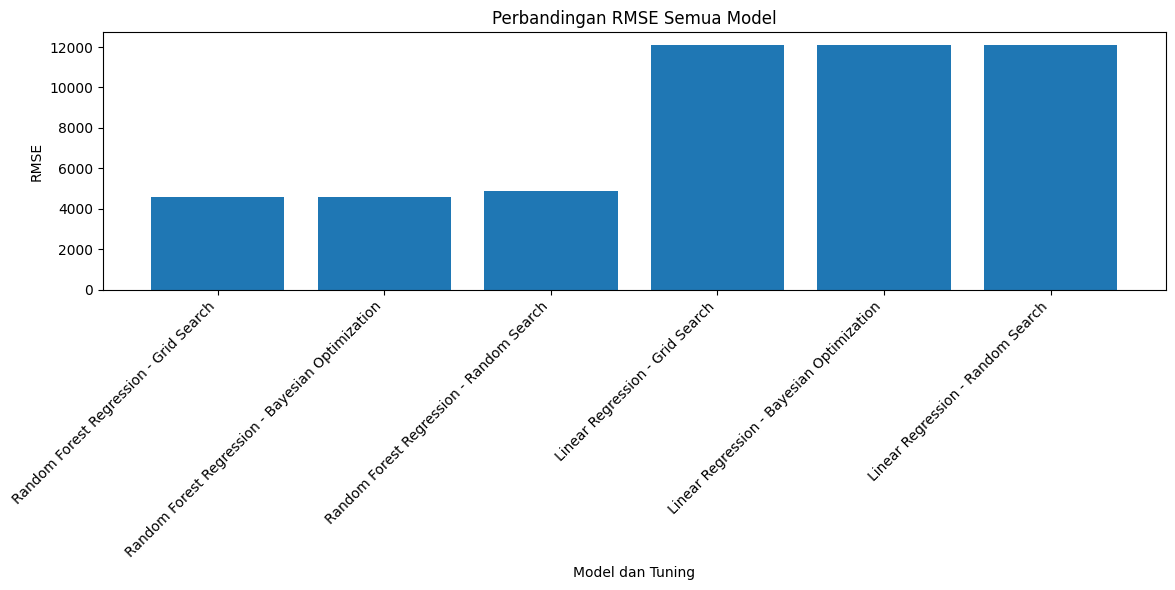

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(hasil_semua_model["Model_Tuning"], hasil_semua_model["RMSE"])
plt.title("Perbandingan RMSE Semua Model")
plt.xlabel("Model dan Tuning")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

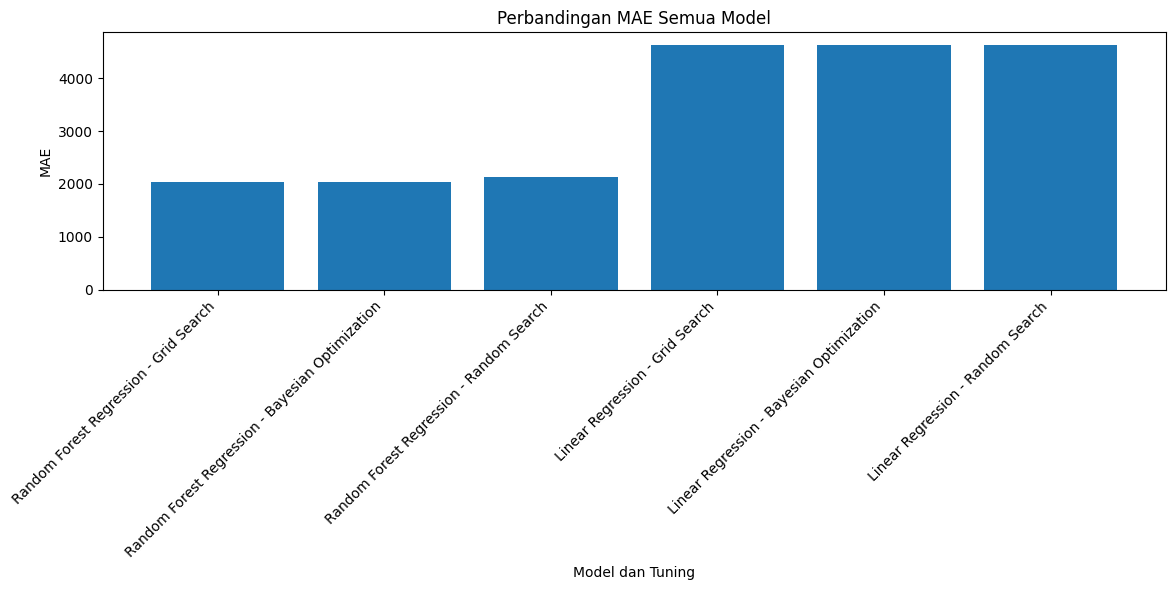

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(hasil_semua_model["Model_Tuning"], hasil_semua_model["MAE"])
plt.title("Perbandingan MAE Semua Model")
plt.xlabel("Model dan Tuning")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

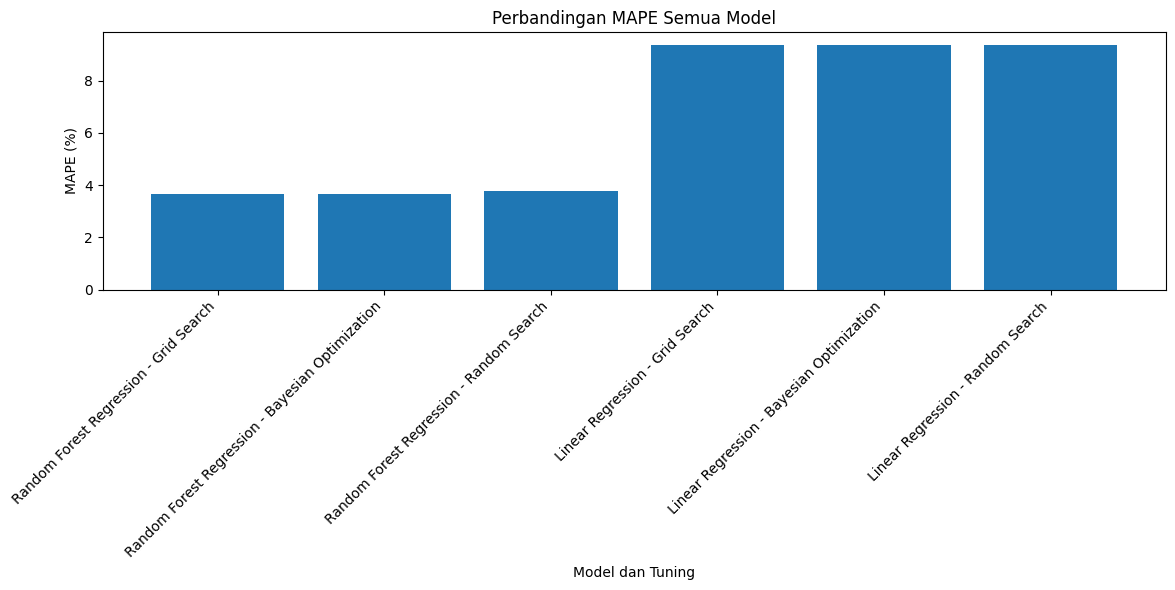

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(hasil_semua_model["Model_Tuning"], hasil_semua_model["MAPE"])
plt.title("Perbandingan MAPE Semua Model")
plt.xlabel("Model dan Tuning")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

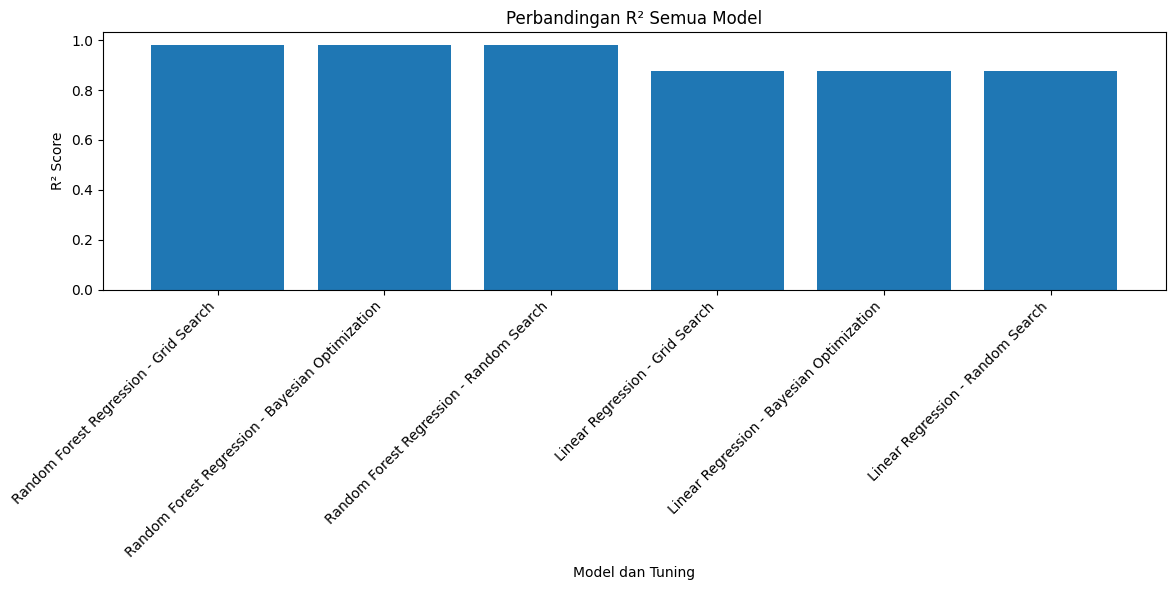

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(hasil_semua_model["Model_Tuning"], hasil_semua_model["R2"])
plt.title("Perbandingan R² Semua Model")
plt.xlabel("Model dan Tuning")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

###Tabel Prediksi Aktual vs Prediksi

,Tanggal,Tahun,Bulan,Harga,Harga_Aktual,Harga_Prediksi,Absolute_Error
760,2025-04-01,2025,4,77710.0,52738.0,61821.223132,9083.223132
761,2025-04-01,2025,4,20694.0,20798.0,20623.022324,174.977676
762,2025-04-01,2025,4,44516.0,39639.0,41631.913504,1992.913504
763,2025-04-01,2025,4,10715.0,10821.0,10684.045252,136.954748
764,2025-04-01,2025,4,11669.0,11626.0,11750.552365,124.552365
765,2025-04-01,2025,4,29149.0,29108.0,29448.066049,340.066049
766,2025-04-01,2025,4,35420.0,34814.0,36073.427251,1259.427251
767,2025-04-01,2025,4,58560.0,49512.0,56138.724654,6626.724654
768,2025-04-01,2025,4,41368.0,40823.0,41136.601531,313.601531
769,2025-04-01,2025,4,15563.0,15595.0,15555.576244,39.423756


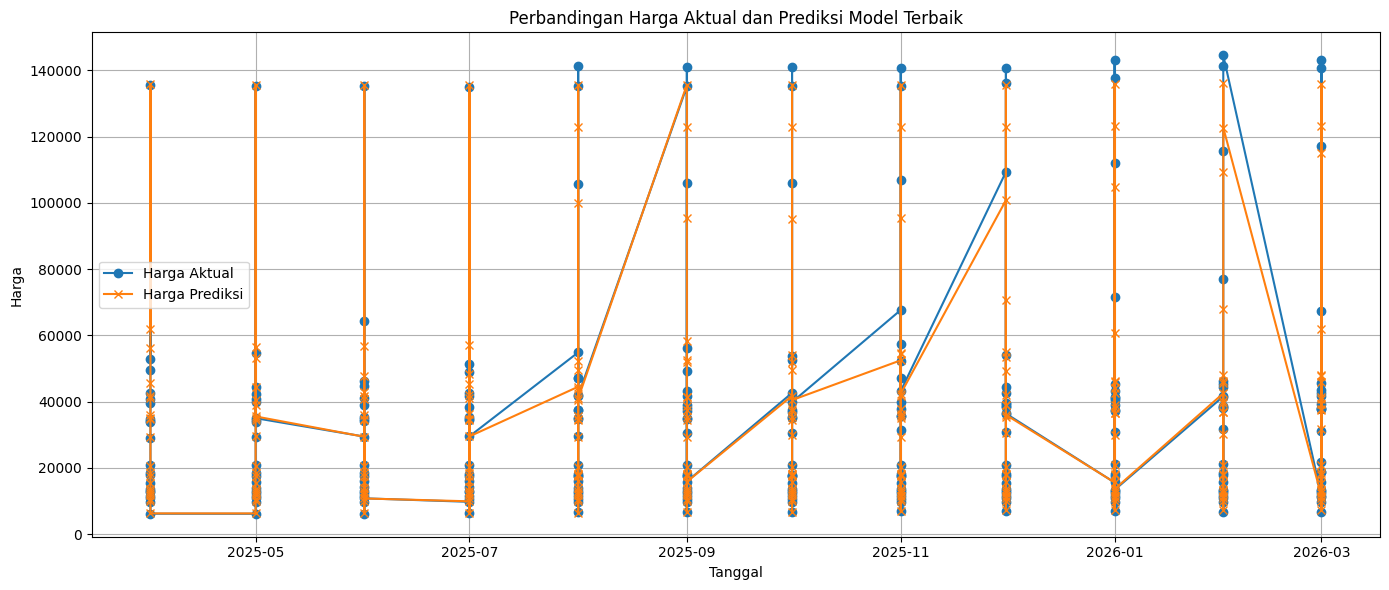

In [ ]:
hasil_prediksi = test_data.copy()

hasil_prediksi["Harga_Aktual"] = y_test.values
hasil_prediksi["Harga_Prediksi"] = y_pred_terbaik
hasil_prediksi["Absolute_Error"] = abs(
    hasil_prediksi["Harga_Aktual"] - hasil_prediksi["Harga_Prediksi"]
)

display(
    hasil_prediksi[
        [
            "Tanggal",
            "Tahun",
            "Bulan",
            "Harga",
            "Harga_Aktual",
            "Harga_Prediksi",
            "Absolute_Error"
        ]
    ].head(20)
)

plt.figure(figsize=(14, 6))

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Harga_Aktual"],
    marker="o",
    label="Harga Aktual"
)

plt.plot(
    hasil_prediksi["Tanggal"],
    hasil_prediksi["Harga_Prediksi"],
    marker="x",
    label="Harga Prediksi"
)

plt.title("Perbandingan Harga Aktual dan Prediksi Model Terbaik")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

###simpan model

In [ ]:
hasil_semua_model.to_csv("hasil_evaluasi_semua_model.csv", index=False)

fold_lr_grid.to_csv("fold_lr_grid_search.csv", index=False)
fold_lr_random.to_csv("fold_lr_random_search.csv", index=False)
fold_lr_bayes.to_csv("fold_lr_bayesian_optimization.csv", index=False)

fold_rf_grid.to_csv("fold_rf_grid_search.csv", index=False)
fold_rf_random.to_csv("fold_rf_random_search.csv", index=False)
fold_rf_bayes.to_csv("fold_rf_bayesian_optimization.csv", index=False)

hasil_prediksi.to_csv("hasil_prediksi_model_terbaik.csv", index=False)

print("Semua hasil modeling berhasil disimpan.")

Semua hasil modeling berhasil disimpan.


In [ ]:
import joblib

joblib.dump(model_terbaik, "model_terbaik_harga_pangan.pkl")

print("Model terbaik berhasil disimpan.")

Model terbaik berhasil disimpan.
